## IMDB sentiment analysis using NLP
- The goal of this task is to determine the best classifier of movie reviews into positive and negative sentiments using  traditional and deep learning machine models for comparison. 

In [1]:
# # install gensim
# !pip install gensim

## Needed python libraries for this task

In [2]:
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import re
from tqdm import tqdm
from gensim.models import Phrases
from gensim.models.phrases import Phraser
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [3]:
# Libraries for building traditional learning models
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [4]:
# Libraries for deep learning models
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping
from transformers import TFBertForSequenceClassification, BertTokenizer, BertTokenizerFast

## Load the Dataset

In [5]:
# Load dataset
imdb_df = pd.read_csv("IMDB Dataset.csv")

In [6]:
# display dataframe
imdb_df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Data Cleaning

- Turn all text to lowercase
- Remove HTML tags and punctuations

```
# function definition to clean text
def clean_text(text)
```

In [7]:
def clean_text(text):
    """
    turn text to lowecase using .lower(), remove punctuations, etc
    Return text
    """
    text = re.sub(r'<.*?>', ' ', text)          # Remove HTML tags
    text = re.sub(r'[^a-zA-Z]', ' ', text)      # Remove punctuation/numbers
    text = text.lower()                         # Lowercase text

    return text

In [8]:
# Invoke function to apply changes
imdb_df['cleaned_review'] = imdb_df['review'].apply(clean_text)
imdb_df[['review', 'cleaned_review']].head()

,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming t...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei s love in the time of money is...


## Tokenization, Stopword Removal, Lemmatization
- Splitting text into words or word pieces
- Remove stopwards (default/custom) using spacy
- Keep meaningful words by filtering POS {'NOUN', 'ADJ', 'VERB', 'ADV'}
- Apply changes to dataframe using progress bar `tqdm.pandas()`

In [9]:
# Tokenize, Lemmatize, Remove stopwords, Filter POS
# Since NOUN, ADJ, VERB, ADV hold meaningful words, I will keep them
allowed_postags = {'NOUN', 'ADJ', 'VERB', 'ADV'}

def preprocess_text(text):
    doc = nlp(text)
    # Create an empty list to append broken words into
    tokens = []
    for token in doc:
        if token.text in stopwords:  # Remove stopwords
            continue
        if token.pos_ not in allowed_postags:  # Keep only selected POS
            continue
        tokens.append(token.lemma_.lower())  # Lemmatize and lowercase
    return tokens

In [10]:
# Add custom stopwords in conjuction with default stopwords from nltk
custom_stopwords = set(stopwords.words('english')).union({
    'movie', 'film'})

In [11]:
# Load spaCy model
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
allowed_postags = {'NOUN', 'ADJ', 'VERB', 'ADV'}

# Updated preprocessing function
def preprocess_text(text):
    doc = nlp(text)
    # Use list comprehension to create "tokens" list
    tokens = [
        token.lemma_
        for token in doc
        if token.pos_ in allowed_postags             # POS filter to fetch desirable words
        and token.lemma_.lower() not in custom_stopwords
        and token.lemma_.isalpha()
    ]
    return tokens

### The lines of code commented below is to avoid rerun as it takes too long a time to finish. The output was saved into a new csv file called `imdb_tokens_dataset` that would be used.

In [12]:
# # Apply progress bar to see runtime for effected change
# tqdm.pandas()
# imdb_df['tokens'] = imdb_df['cleaned_review'].progress_apply(preprocess_text)

In [13]:
# # Display to see the first 5 rows
# imdb_df.head()

## Save into a csv file for reuse

In [14]:
# # I am saving to a csv file, to avoid the long running of the initial code
# # Save the 2 most important columns to csv
# imdb_df_to_save = imdb_df[['tokens', 'sentiment']]
# imdb_df_to_save.to_csv('imdb_tokens_dataset.csv', index=False)

In [15]:
# Read the new saved csv file
imdb_df = pd.read_csv("imdb_tokens_dataset.csv")
# Display 5 rows
imdb_df.head()

,tokens,sentiment
0,"['reviewer', 'mention', 'watch', 'episode', 'h...",positive
1,"['wonderful', 'little', 'production', 'filming...",positive
2,"['think', 'wonderful', 'way', 'spend', 'time',...",positive
3,"['basically', 'family', 'little', 'boy', 'jake...",negative
4,"['petter', 'mattei', 'love', 'time', 'money', ...",positive


In [16]:
# Convert the stringified lists to actual Python lists
imdb_df['tokens'] = imdb_df['tokens'].apply(ast.literal_eval)

# Then store the 'tokens' column as a list of lists in imdb_df
imdb_df['tokens'] = imdb_df['tokens'].tolist()

In [17]:
# Confirm the stringified list is now an actual Python list
imdb_df.head()

,tokens,sentiment
0,"[reviewer, mention, watch, episode, hook, righ...",positive
1,"[wonderful, little, production, filming, techn...",positive
2,"[think, wonderful, way, spend, time, hot, summ...",positive
3,"[basically, family, little, boy, jake, think, ...",negative
4,"[petter, mattei, love, time, money, visually, ...",positive


## Bigram and Trigram Modeling
Both give better context to word classification than unigrams
- Bigrams: To capture meaning from two-word combination (i.e unigrams)
- Trigrams: To capture meaning from three-word combination (i.e bigrams)

In [18]:
# Build bigram and trigram models from unigram (imdb_df['tokens'])
bigram = Phrases(imdb_df['tokens'], min_count=5, threshold=10) # min_count=5 (should appear atleast 5 times)
trigram = Phrases(bigram[imdb_df['tokens']], threshold=10) # threshold=10 for moderate acceptance of phrases

bigram_mod = Phraser(bigram)
trigram_mod = Phraser(trigram)

In [19]:
# Apply the bigram and trigram models
def make_bigrams(texts):
    return bigram_mod[texts]

def make_trigrams(texts):
    return trigram_mod[bigram_mod[texts]]

# Effect changes on dataframe
imdb_df['tokens_bigrams'] = imdb_df['tokens'].apply(make_bigrams)
imdb_df['tokens_trigrams'] = imdb_df['tokens_bigrams'].apply(make_trigrams)


In [20]:
# Display output to view bigrams and trigrams
imdb_df[["tokens_bigrams", "tokens_trigrams"]].head()

,tokens_bigrams,tokens_trigrams
0,"[reviewer_mention, watch, episode, hook, right...","[reviewer_mention, watch, episode, hook, right..."
1,"[wonderful, little, production, filming_techni...","[wonderful, little, production, filming_techni..."
2,"[think, wonderful, way, spend_time, hot_summer...","[think, wonderful, way, spend_time, hot_summer..."
3,"[basically, family, little, boy, jake, think, ...","[basically, family, little_boy, jake, think, z..."
4,"[petter, mattei, love, time, money, visually_s...","[petter, mattei, love, time, money, visually_s..."


## Prepare tokens for Text Vectorization
- Make text ready for TF-IDF or CountVectorizer input

In [21]:
# Rejoin tokens into text for proper vectorization
imdb_df['processed_text'] = imdb_df['tokens_trigrams'].apply(lambda x: ' '.join(x))

# View processed_text and sentiment values
imdb_df[['processed_text', 'sentiment']].head()

,processed_text,sentiment
0,reviewer_mention watch episode hook right exac...,positive
1,wonderful little production filming_technique ...,positive
2,think wonderful way spend_time hot_summer week...,positive
3,basically family little_boy jake think zombie ...,negative
4,petter mattei love time money visually_stunnin...,positive


## Generate WordCloud
- Visualise the most frequent terms in the processed_text
- Save WordCloud into a pdf file

In [22]:
# Generates a wordcloud of the most frequently occuring texts
def get_wordcloud(hashtags, max_font_size=40, save_path='wordcloud_all.pdf', dpi=300):
    """
    Generates and displays a word cloud from a list of words or hashtags.

    Parameters:
        hashtags (list or iterable): List of words or hashtags.
        max_font_size (int): Maximum font size for the largest word.
        save_path (str): Path to save the word cloud image as PDF.
        dpi (int): Dots per inch for saved figure quality.

    Returns:
        None
    """

    # Combine all hashtags into a single string
    text = ' '.join(hashtags)

    # Create the word cloud object
    wordcloud = WordCloud(max_font_size=max_font_size, background_color='white').generate(text)

    # Plot the word cloud
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.tight_layout()

    # Save the image
    plt.savefig(save_path, dpi=dpi)
    plt.show()


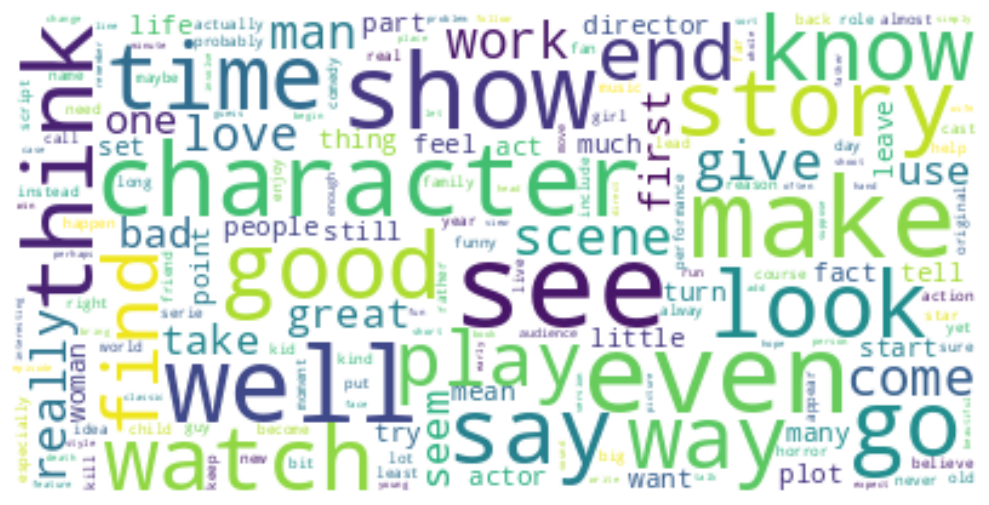

In [23]:
# Display and save wordcloud as a pdf file
get_wordcloud(hashtags=imdb_df['processed_text'], max_font_size=50, save_path='movie_wordcloud.pdf')

## Traditional Machine Learning Models
The traditional machine learning models built are of supervised types with the exception of k-Means which is unsupervised;
`naive_bayes`, `k-Means`, `svm`, `logistic_regression`, and `random-forest`

In [24]:
# TF-IDF vectorizer
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(imdb_df['processed_text'])

# True Labels
y = imdb_df['sentiment']
# Convert sentiment to binary labels: positive → 1, negative → 0
y_binary = imdb_df['sentiment'].map({'positive': 1, 'negative': 0})

In [25]:
# Display shape
X.shape

(50000, 5000)

In [26]:
# Display shape
y_binary.shape

(50000,)

In [27]:
# Confirm the distribution of sentiment labels
label_distribution = y_binary.value_counts()
label_distribution

,count
sentiment,
1,25000
0,25000


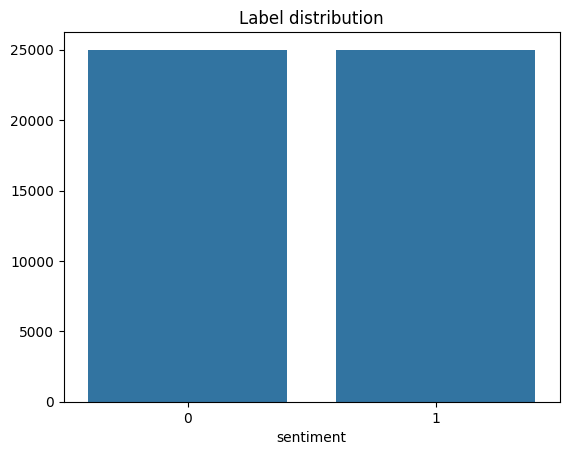

In [28]:
# A quick bar plot to see the distribution
label_plot = sns.barplot(x=label_distribution.index, y=label_distribution.values)
# Label the axis
plt.title('Label distribution')
# Show plot
plt.show()

In [29]:
# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

In [30]:
# Confirm training set are balanced
print(f"{sum(y_train == 1)} positive reviews")
print(f"{sum(y_train == 0)} negative reviews")

20000 positive reviews
20000 negative reviews


### Re-useable Functions for traditional models
The functions below are created to reduce boiler plate codes and test parameters that improves training and validation

```

# Build traditional model (supervised) e.g naive_bayes
def traditional_model(X_train, y_train, X_test, y_test, model_name)


# Plot confusion matrix for built model (supervised)
def trad_model_conf_mat(y_true, y_pred, model_name)

# Plot k-Means PCA comparison function
def plot_pred_true_clusters(X, predicted_clusters, true_labels)

```

In [31]:
# A function that allows re-use of code for different model
def traditional_model(X_train, y_train, X_test, y_test, model_name):
    """
    Trains and evaluates a traditional ML model for NLP tasks.
    If model_name='all', evaluates all models and returns a DataFrame comparison.
    """

    # Map model names to their corresponding scikit-learn models
    model_dict = {
        "naive_bayes": MultinomialNB(),
        "logistic_regression": LogisticRegression(max_iter=1000),
        "svm": LinearSVC(),
        "random_forest": RandomForestClassifier()
    }

    valid_models = list(model_dict.keys())

    # Run all models to show comparison table
    if model_name == "all":
        results = []
        for name in valid_models:
            model = model_dict[name]
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            # evaluation metrics
            accuracy = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)

            results.append({
                "Model": name.replace("_", " ").title(),
                "Accuracy": round(accuracy * 100, 2),
                "F1-score": round(f1 * 100, 2)
            })

        results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
        print("\nModel Performance Summary:")
        print(results_df)
        return results_df

    # Single model mode
    elif model_name in valid_models:
        model = model_dict[model_name]
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        report = classification_report(y_test, y_pred)

        print(f"Classification Report for {model_name}:")
        print(f"Accuracy: {round(accuracy * 100, 2)}%")
        print(f"F1-score: {round(f1 * 100, 2)}%")
        print(report)

        return {
            "model": model,
            "predictions": y_pred,
            "accuracy": accuracy,
            "f1_score": f1,
            "report": report
        }

    else:
        raise ValueError(f"Invalid model name. Choose from {valid_models} or 'all'.")

In [32]:
# A function to create a confusion matrix for all traditional models
def trad_model_conf_mat(y_true, y_pred, model_name):
    """
    Plots a confusion matrix using Seaborn heatmap.

    Parameters:
        y_true (array-like): True class labels
        y_pred (array-like): Predicted class labels
        title (str, optional): Title of the plot
    """
    # Generate the confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Create a heatmap
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{model_name} Confusion Matrix")

    # Add label
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    # Show confusion matrix
    plt.show()

### Supervised Learning Traditional Models

### All Model
- This shows only the comparison of all the models in a table using accuracy_score

In [33]:
# Comparison table
trad_all_model = traditional_model(X_train, y_train, X_test, y_test, model_name="all")


Model Performance Summary:
                 Model  Accuracy  F1-score
0  Logistic Regression     88.27     88.39
1                  Svm     87.69     87.77
2          Naive Bayes     85.62     85.80
3        Random Forest     83.59     83.49


#### Naive Bayes Model
- Classification report (Accuracy)
- Confusion Matrix

In [34]:
# classification report for naive bayes
# invoke the "traditional_model" function to get result for naive bayes
nb_model = traditional_model(X_train, y_train, X_test, y_test, model_name="naive_bayes")

Classification Report for naive_bayes:
Accuracy: 85.62%
F1-score: 85.8%
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      5000
           1       0.85      0.87      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



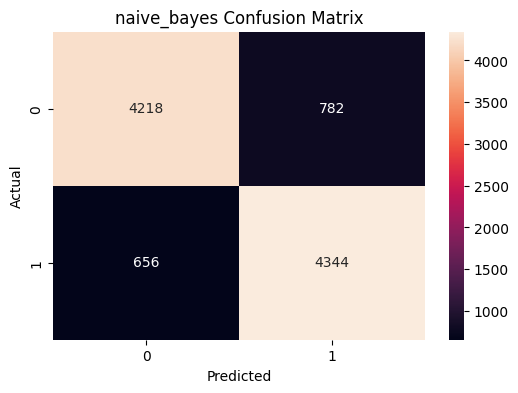

In [35]:
# Plot confusion matrix for Naive Bayes
nb_conf_mat = trad_model_conf_mat(y_true=y_test, y_pred=nb_model["predictions"], model_name="naive_bayes")

#### Support Vector Machines (SVM) Model
- Classification report (Accuracy)
- Confusion Matrix

In [36]:
# classification report for svm
# invoke the "traditional_model" function to get result for svm
svm_model = traditional_model(X_train, y_train, X_test, y_test, model_name="svm")

Classification Report for svm:
Accuracy: 87.69%
F1-score: 87.77%
              precision    recall  f1-score   support

           0       0.88      0.87      0.88      5000
           1       0.87      0.88      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



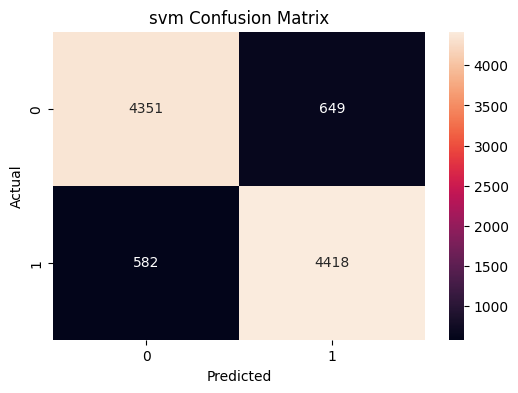

In [37]:
# Plot confusion matrix for SVM
svm_conf_mat = trad_model_conf_mat(y_true=y_test, y_pred=svm_model["predictions"], model_name="svm")

#### Comparison of Accuracy
Out of curiosity, I decided to check the accuracy level of other well known traditional models (supervised) such as;
`Logistic Regression`, `Random Forest`

#### Logistic regression Model
- Classification report (Accuracy)
- Confusion Matrix

In [38]:
# classification report for logistic regression
# invoke the "traditional_model" function to get result for logistic_regression
lr_model = traditional_model(X_train, y_train, X_test, y_test, model_name="logistic_regression")

Classification Report for logistic_regression:
Accuracy: 88.27%
F1-score: 88.39%
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      5000
           1       0.87      0.89      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



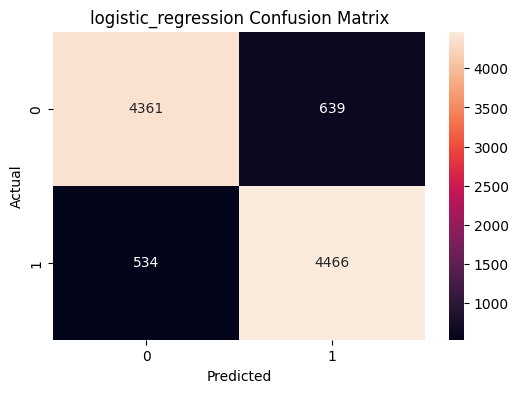

In [39]:
# Plot confusion matrix for logistic regression
lr_conf_mat = trad_model_conf_mat(y_true=y_test, y_pred=lr_model["predictions"], model_name="logistic_regression")

#### Random Forest Model
- Classification report (Accuracy)
- Confusion Matrix

In [40]:
# classification report for random forest
# invoke the "traditional_model" function to get result for random forest
rf_model = traditional_model(X_train, y_train, X_test, y_test, model_name="random_forest")

Classification Report for random_forest:
Accuracy: 83.87%
F1-score: 83.78%
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      5000
           1       0.84      0.83      0.84      5000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



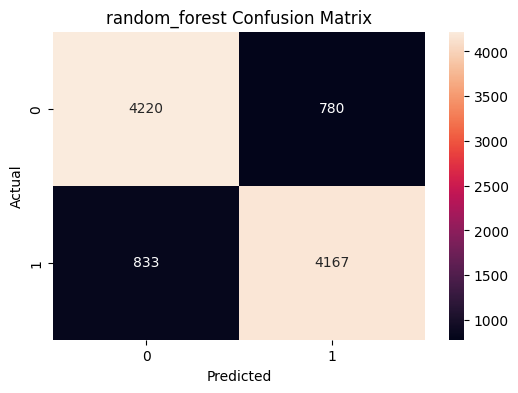

In [41]:
# Plot confusion matrix for knn
rf_conf_mat = trad_model_conf_mat(y_true=y_test, y_pred=rf_model["predictions"], model_name="random_forest")

### Unsupervised Learning Traditional method (Clustering)
The other traditional model under unsupervised learning that I would be trying out is `k-Means`
- Check accuracy and classification report
- PCA visualisations to compare predicted clusters to true labels

#### k-Means

In [42]:
# Create K-Means model using the known 2 sentiment classes
kmeans = KMeans(n_clusters=2, random_state=42)
# X has already been vectorised from earlier steps
kmeans.fit(X)

# Cluster labels predicted by K-Means
predicted_clusters = kmeans.labels_

# True label from the sentiment column
true_labels = imdb_df['sentiment'].map({'positive': 1, 'negative': 0})

# Evaluate the Model
km_accuracy = accuracy_score(true_labels, predicted_clusters)
km_f1 = f1_score(true_labels, predicted_clusters)
km_report = classification_report(true_labels, predicted_clusters)

# Create a DataFrame for K-Means result
kmeans_df = pd.DataFrame([{
    "Model": "K-Means Clustering",
    "Accuracy": round(km_accuracy * 100, 2),
    "F1-score": round(km_f1 * 100, 2)
}])

# Print to check
print(f"{kmeans_df}")
print()
print()
print(f"K-Means Clustering Accuracy: {round(km_accuracy * 100, 2)}%")
print(f"Classification Report for k-Means: \n{km_report}")


                Model  Accuracy  F1-score
0  K-Means Clustering     63.74     68.02


K-Means Clustering Accuracy: 63.74%
Classification Report for k-Means: 
              precision    recall  f1-score   support

           0       0.69      0.50      0.58     25000
           1       0.61      0.77      0.68     25000

    accuracy                           0.64     50000
   macro avg       0.65      0.64      0.63     50000
weighted avg       0.65      0.64      0.63     50000



#### Visualise k-Means
Use PCA plots to compare predicted clusters with true labels

```
# plot k-Means comparison function
def plot_pred_true_clusters(X, predicted_clusters, true_labels)
```

In [43]:
# Function to compare predicted labels with true labels using PCA
def plot_pred_true_clusters(X, predicted_clusters, true_labels):
    """
    Plots PCA visualizations of K-Means clusters and actual sentiment labels side-by-side.

    Parameters:
        X (sparse matrix): TF-IDF transformed text data.
        predicted_clusters (array-like): Cluster labels from K-Means.
        true_labels (array-like): Ground truth binary sentiment labels (0 or 1).
    """
    # Apply PCA
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X.toarray())  # Convert sparse to dense

    # Create a DataFrame for plotting
    pca_df = pd.DataFrame({
        'PC1': X_pca[:, 0],
        'PC2': X_pca[:, 1],
        'Cluster': predicted_clusters,
        'Sentiment': true_labels
    })

    # Plot by predicted KMeans clusters
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='viridis', alpha=0.7)
    plt.title("PCA - KMeans Cluster Labels")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend(title="Cluster")
    plt.grid(True)

    # Plot using the actual sentiment
    plt.subplot(1, 2, 2)
    sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Sentiment', palette='coolwarm', alpha=0.7)
    plt.title("PCA - Actual Sentiment Labels")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend(title="Sentiment")
    plt.grid(True)

    # Show both plots together
    plt.tight_layout()
    plt.show()


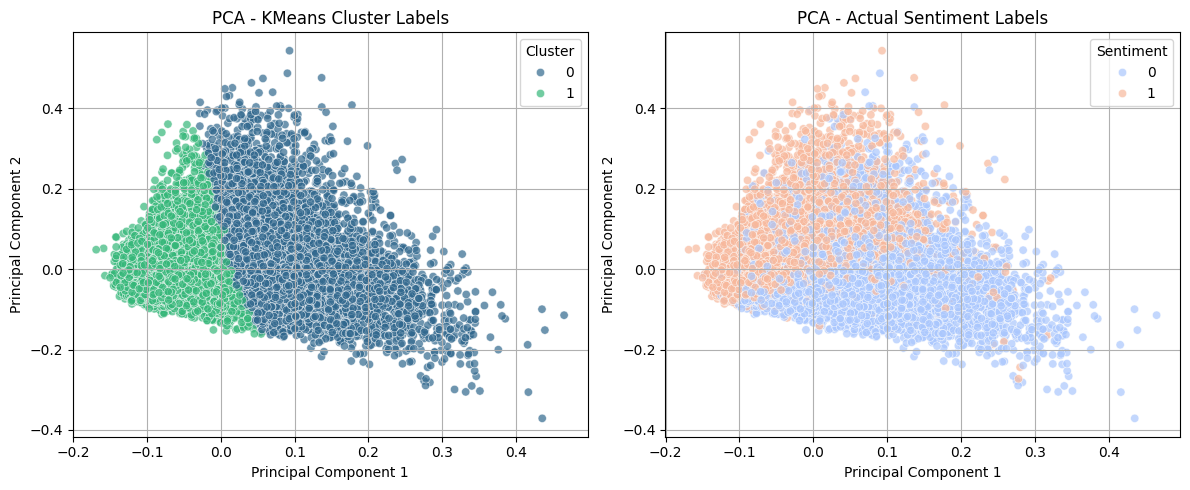

In [44]:
plot_pred_true_clusters(X, predicted_clusters, true_labels)

#### Traditional Model Comparison
- Supervised and unsupervised learning methods

In [45]:
# Compare results of traditional models by accuracy
trad_comparison_df = pd.concat([trad_all_model, kmeans_df], ignore_index=True)
trad_comparison_df = trad_comparison_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
print(trad_comparison_df)

                 Model  Accuracy  F1-score
0  Logistic Regression     88.27     88.39
1                  Svm     87.69     87.77
2          Naive Bayes     85.62     85.80
3        Random Forest     83.59     83.49
4   K-Means Clustering     63.74     68.02


## Deep Learning models
The deep learning models that will be built are;
`GRU`, and `LSTM`

- Use a tokenizer with `set max_vocab`, `max_len`, and `embedding_dim`
- Pad sequences, then split data to 80% training and 20% testing sets

In [46]:
# Tokenization using Keras tokenizer
max_vocab = 10000
max_len = 200
embedding_dim = 64

tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tokenizer.fit_on_texts(imdb_df['processed_text'])

# Padding sequences to the same length
sequences = tokenizer.texts_to_sequences(imdb_df['processed_text'])
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

In [47]:
# # Split the data
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(padded_sequences, y_binary, test_size=0.2,
                                                                random_state=42, stratify=y_binary)

### Re-useable functions for Deep Learning Models
The functions below are created to reduce boiler plate codes and test parameters that improves training and validation

```
# Build the deep model (default parameters)
def build_rnn_model(vocab_size=max_vocab,
                    embedding_dim=embedding_dim,
                    input_length=max_len,
                    units=[64],
                    dropout_rate=0.3,
                    recurrent_dropout_rate=0.2,
                    optimizer_name='adam',
                    learning_rate=0.001,
                    use_early_stop=False,
                    patience=2,
                    model_type='lstm')

# Accuracy and loss plot
def plot_rnn_training_history(history, metric='loss', model_type='', optimiser='')

# Evaluate deep models by classification report/confusion matrix
def evaluate_deep_model(model, X_test_dl, y_test_dl, cap="GRU")
```

In [48]:
def build_rnn_model(vocab_size=max_vocab,
                    embedding_dim=embedding_dim,
                    input_length=max_len,
                    units=[64],
                    dropout_rate=0.3,
                    recurrent_dropout_rate=0.2,
                    optimizer_name='adam',
                    learning_rate=0.001,
                    use_early_stop=False,
                    patience=2,
                    model_type='lstm'):
    """
    Builds a customizable LSTM or GRU model with 1 or 2 layers for binary text classification.

    Parameters:
        vocab_size (int): Vocabulary size (default: 10000)
        embedding_dim (int): Dimension of word embeddings (default: 64)
        input_length (int): Length of input sequences (default: 200)
        units (list): One or two layer units, e.g., [64] or [64, 64], (default: [64])
        dropout_rate (float): Dropout after RNN layer(s)
        recurrent_dropout_rate (float): Dropout inside RNN cell
        optimizer_name (str): 'adam' or 'rmsprop'
        learning_rate (float): Learning rate for optimizer
        use_early_stop (bool): Whether to use EarlyStopping
        patience (int): Number of epochs before stopping early
        model_type (str): 'lstm' or 'gru'

    Returns:
        model: Compiled Keras model
        callbacks: List of callbacks (may be empty)
    """
    # Check that model name is lstm or gru, else else error
    if model_type.lower() not in {'lstm', 'gru'}:
        raise ValueError("model_type must be 'lstm' or 'gru'")

    # Confirm the number of unit layers does not exceed 2, else raise error
    if not isinstance(units, list) or len(units) not in {1, 2}:
        raise ValueError("units must be a list of one or two integers, e.g., [64] or [64, 64]")

    RNNLayer = LSTM if model_type.lower() == 'lstm' else GRU

    # Optimizer setup
    if optimizer_name.lower() == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_name.lower() == 'rmsprop':
        optimizer = RMSprop(learning_rate=learning_rate)
    else:
        raise ValueError("optimizer_name must be 'adam' or 'rmsprop'")

    # Build the RNN model
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=input_length))

    # First RNN layer
    model.add(RNNLayer(units[0],
                       return_sequences=(len(units) == 2),
                       dropout=dropout_rate,
                       recurrent_dropout=recurrent_dropout_rate))

    # In cases of a second RNN layer, then apply return_sequences to the first
    if len(units) == 2:
        model.add(RNNLayer(units[1],
                           dropout=dropout_rate,
                           recurrent_dropout=recurrent_dropout_rate))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    # Compile the model
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    # Callbacks
    callbacks = []
    if use_early_stop:
        callbacks.append(EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True))

    return {
        'model': model,
        'callbacks': callbacks
    }

In [49]:
def plot_rnn_training_history(history, metric='loss', model_type='', optimiser=''):
    """
    Plots training and validation curves for a specified metric.

    Parameters:
    - history: Keras History object returned from model.fit()
    - metric: str, either 'loss' or 'accuracy'
    - title_suffix: Optional string to append to the plot title (e.g., ' (Adam)')
    """
    if metric not in ['loss', 'accuracy']:
        raise ValueError("metric must be either 'loss' or 'accuracy'")

    # Get the metric values from history
    train_metric = history.history.get(metric)
    val_metric = history.history.get(f'val_{metric}')

    if train_metric is None or val_metric is None:
        raise ValueError(f"{metric} or val_{metric} not found in training history.")

    # Define plot title and ylabel
    title = f'{model_type} Training and Validation {metric.capitalize()}{optimiser}'
    ylabel = 'Loss (Cross-Entropy)' if metric == 'loss' else 'Accuracy'

    plt.plot(train_metric, label=f'Training {metric.capitalize()}')
    plt.plot(val_metric, label=f'Validation {metric.capitalize()}')
    # add labels
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    # show plot
    plt.show()


In [50]:
# A function to evaluate deep models by classification report/confusion matrix
def evaluate_deep_model(model, X_test_dl, y_test_dl, cap="GRU"):
    """
    Evaluate a model by generating predictions,
    a classification report, and a confusion matrix.

    Parameters:
    - model: Trained Keras model
    - X_test: Test feature set
    - y_test: Test labels
    - cap: model name for plot title

    Returns:
    - None
    """
    # Make predictions
    y_pred_dl_prob = model.predict(X_test_dl)
    y_pred_dl = (y_pred_dl_prob > 0.5).astype(int)  # Binary classification threshold

    # Classification report/accuracy
    accuracy = accuracy_score(y_test_dl, y_pred_dl)
    f1 = f1_score(y_test_dl, y_pred_dl)
    report = classification_report(y_test_dl, y_pred_dl)
    # Print Classification Report
    print(f"Classification Report for {cap}:")
    print(f"Accuracy: {round(accuracy * 100, 2)}%")
    print(f"{report}")

    # Confusion matrix
    cm = confusion_matrix(y_test_dl, y_pred_dl)

    # Plot confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cbar=True)
    # Add labels
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{cap} Confusion Matrix')
    # Show Plot
    plt.show()

    # Return metrics for summary table
    return {
        'Model': cap,
        'Accuracy': accuracy,
        'F1-Score': f1
    }


### GRU Model using adam optimiser
Default set up before applying hyperparameter
```
dropout_rate=0.3
unit=64
batchsize=64
early_stop, with patience=2
embedding_dim=64
```


In [51]:
# GRU model (adam) and callbacks
gru_defa_result = build_rnn_model(
    model_type='gru',
    units=[64],
    use_early_stop=False
)

# Access the model and callbacks
gru_defa_model = gru_defa_result['model']
gru_defa_callbacks = gru_defa_result['callbacks']

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [52]:
# Fit the model
gru_defa_history = gru_defa_model.fit(
    X_train_dl, y_train_dl,
    validation_data=(X_test_dl, y_test_dl),
    epochs=5,
    batch_size=64
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 257s 397ms/step - accuracy: 0.5035 - loss: 0.6932 - val_accuracy: 0.5119 - val_loss: 0.6926
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 255s 396ms/step - accuracy: 0.5187 - loss: 0.6889 - val_accuracy: 0.5527 - val_loss: 0.6844
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 244s 390ms/step - accuracy: 0.7405 - loss: 0.5290 - val_accuracy: 0.8673 - val_loss: 0.3231
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 246s 393ms/step - accuracy: 0.8907 - loss: 0.2780 - val_accuracy: 0.8892 - val_loss: 0.2758
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 264s 396ms/step - accuracy: 0.9219 - loss: 0.2065 - val_accuracy: 0.8870 - val_loss: 0.2783


#### GRU History (Adam)
For GRU default model
- Plot loss and accuracy metric using adam optimizer
- Evaluate using Classifcation Report/Confusion

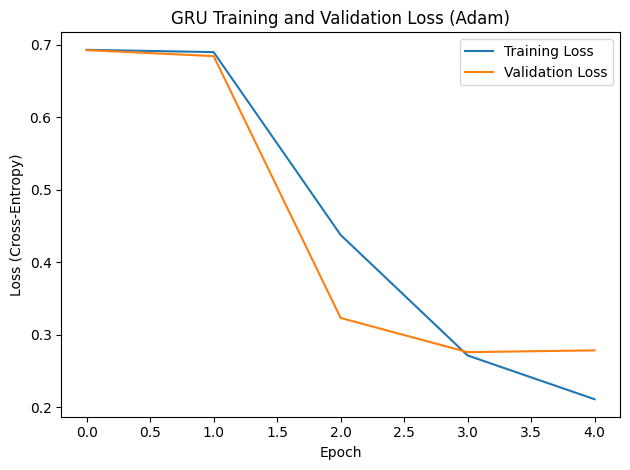

In [53]:
# Plot GRU training loss against validation loss
gru_defa_loss_plot = plot_rnn_training_history(gru_defa_history, metric='loss',
                                                   model_type='GRU', optimiser=' (Adam)')

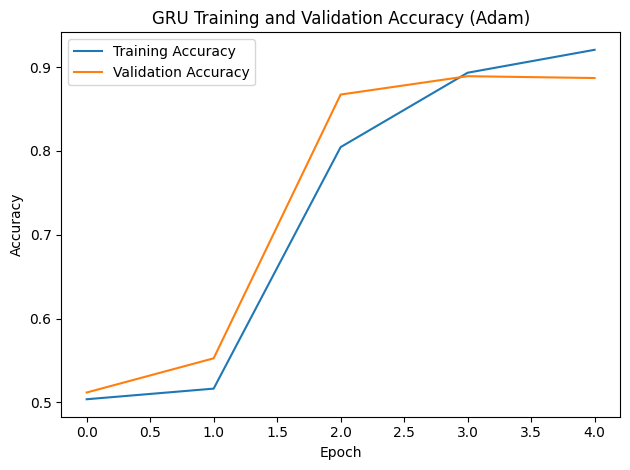

In [54]:
# Plot GRU training accuracy against validation accuracy
gru_defa_acc_plot = plot_rnn_training_history(gru_defa_history, metric='accuracy',
                                                   model_type='GRU', optimiser=' (Adam)')

#### Classifcation Report/Confusion Matrix for GRU (adam)
For GRU default model

313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step
Classification Report for gru_defa_model:
Accuracy: 88.7%
              precision    recall  f1-score   support

           0       0.91      0.86      0.88      5000
           1       0.87      0.91      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



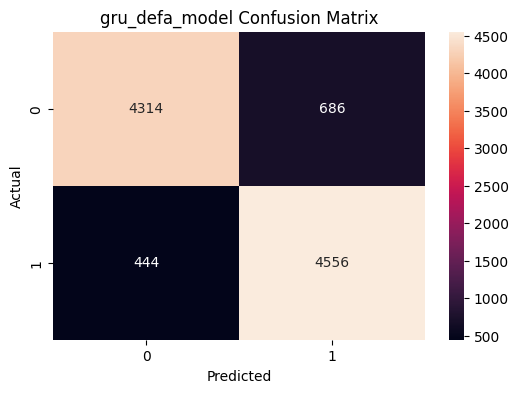

In [56]:
# Invoke function to evaluate models
m_gru_defa_model = evaluate_deep_model(gru_defa_model, X_test_dl, y_test_dl, cap="gru_defa_model")

### LSTM Model using adam optimiser
Default set up before applying hyperparameter
```
dropout_rate=0.3
unit=64
batchsize=64
early_stop, with patience=2
embedding_dim=64
```

In [58]:
# LSTM model and callbacks
lstm_defa_result = build_rnn_model(
    model_type='lstm',
    units=[64],
    use_early_stop=False
)

# Access the model and callbacks
lstm_defa_model = lstm_defa_result['model']
lstm_defa_callbacks = lstm_defa_result['callbacks']

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [59]:
# Fit the model
lstm_defa_history = lstm_defa_model.fit(
    X_train_dl, y_train_dl,
    validation_data=(X_test_dl, y_test_dl),
    epochs=5,
    batch_size=64
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 250s 395ms/step - accuracy: 0.5050 - loss: 0.6931 - val_accuracy: 0.5132 - val_loss: 0.6925
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 246s 393ms/step - accuracy: 0.5196 - loss: 0.6936 - val_accuracy: 0.5012 - val_loss: 0.6916
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 264s 396ms/step - accuracy: 0.5299 - loss: 0.6802 - val_accuracy: 0.5086 - val_loss: 0.6883
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 258s 390ms/step - accuracy: 0.5602 - loss: 0.6451 - val_accuracy: 0.7722 - val_loss: 0.5422
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 249s 398ms/step - accuracy: 0.7791 - loss: 0.5102 - val_accuracy: 0.7047 - val_loss: 0.6201


#### LSTM History (Adam)
For LSTM default model
- Plot loss and accuracy metric using adam optimizer
- Evaluate using Classifcation Report/Confusion

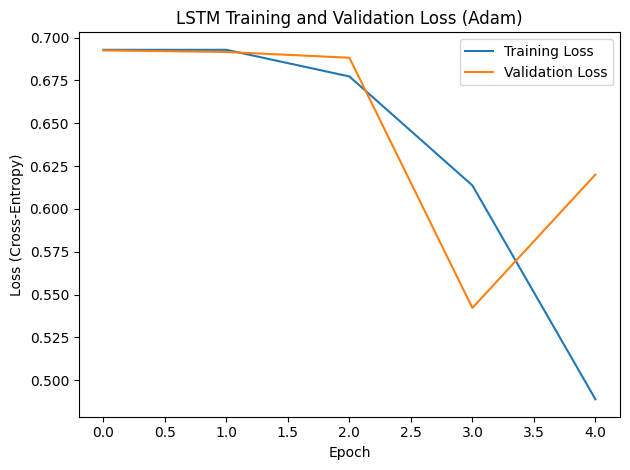

In [60]:
# Plot LSTM training loss against validation loss
lstm_defa_loss_plot = plot_rnn_training_history(lstm_defa_history, metric='loss',
                                                   model_type='LSTM', optimiser=' (Adam)')

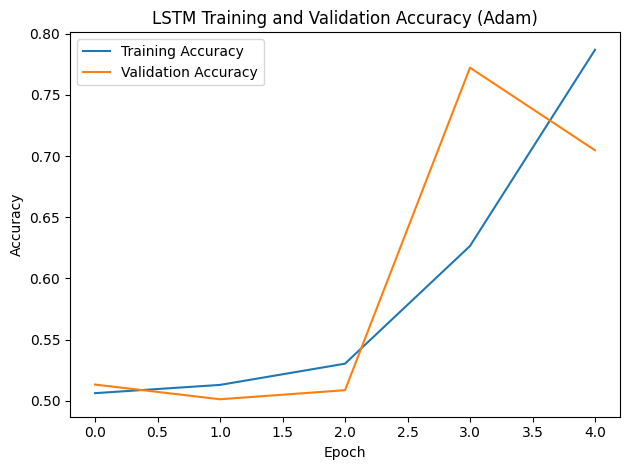

In [61]:
# Plot LSTM training accuracy against validation accuracy
lstm_defa_acc_plot = plot_rnn_training_history(lstm_defa_history, metric='accuracy',
                                                   model_type='LSTM', optimiser=' (Adam)')

#### Classifcation Report/Confusion Matrix for LSTM (adam)
For LSTM default model

313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 115ms/step
Classification Report for lstm_defa_model:
Accuracy: 70.47%
              precision    recall  f1-score   support

           0       0.94      0.44      0.60      5000
           1       0.63      0.97      0.77      5000

    accuracy                           0.70     10000
   macro avg       0.79      0.70      0.68     10000
weighted avg       0.79      0.70      0.68     10000



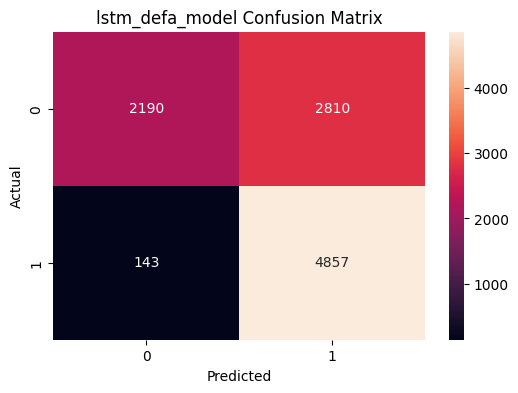

In [62]:
# Invoke function to evaluate models
m_lstm_defa_model = evaluate_deep_model(lstm_defa_model, X_test_dl, y_test_dl, cap="lstm_defa_model")

## Hyperparameter Tuning
The results from the recurrent neural network model are quite reasonable for adam optimizer, but I am curious to see if it could do better
- Tune the various hyperparameters of the model using the best optimizer (Adam)

### GRU Model (Adam)
Dropout is now increased from 0.3 to 0.5, and the unit is now stacked up with two layers [64,64]

```
dropout_rate=0.5
unit=[64, 64]
batch_size=64
early_stop, with patience=2
```
**NB: All other parameters remain the same**

In [64]:
# GRU model (adam) and callbacks
gru_h2l_bs64_result = build_rnn_model(
    model_type='gru',
    units=[64, 64],
    dropout_rate=0.5,
    use_early_stop=True
)

# Access the model and callbacks
gru_h2l_bs64_model = gru_h2l_bs64_result['model']
gru_h2l_bs64_callbacks = gru_h2l_bs64_result['callbacks']

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [65]:
# Fit the model
gru_h2l_bs64_history = gru_h2l_bs64_model.fit(
    X_train_dl, y_train_dl,
    validation_data=(X_test_dl, y_test_dl),
    epochs=10,
    batch_size=64,
    callbacks=gru_h2l_bs64_callbacks
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 484s 766ms/step - accuracy: 0.4961 - loss: 0.6939 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 500s 764ms/step - accuracy: 0.5054 - loss: 0.6929 - val_accuracy: 0.5108 - val_loss: 0.6924
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 502s 763ms/step - accuracy: 0.5251 - loss: 0.6841 - val_accuracy: 0.5128 - val_loss: 0.6955
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 475s 761ms/step - accuracy: 0.5499 - loss: 0.6512 - val_accuracy: 0.8304 - val_loss: 0.4019
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 496s 751ms/step - accuracy: 0.8602 - loss: 0.3494 - val_accuracy: 0.8722 - val_loss: 0.3106
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 509s 763ms/step - accuracy: 0.9068 - loss: 0.2468 - val_accuracy: 0.8812 - val_loss: 0.2882
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 501s 761ms/step - accuracy: 0.9238 - loss: 0.2073 - val_accuracy: 0.8879 - val_loss: 0.2864
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 501s 760ms/step - accuracy: 0.9344 -

#### GRU History (Adam)
For batchsize=64, epochs=10, units=[64,64]
`GRU tuned model`
- Plot loss and accuracy metric using adam optimizer
- Evaluate using Classifcation Report/Confusion

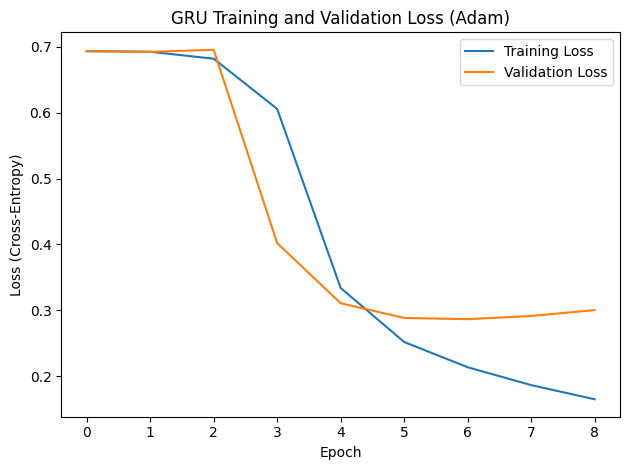

In [66]:
# Plot GRU training loss against validation loss
gru_h2l_bs64_loss_plot = plot_rnn_training_history(gru_h2l_bs64_history, metric='loss',
                                                   model_type='GRU', optimiser=' (Adam)')

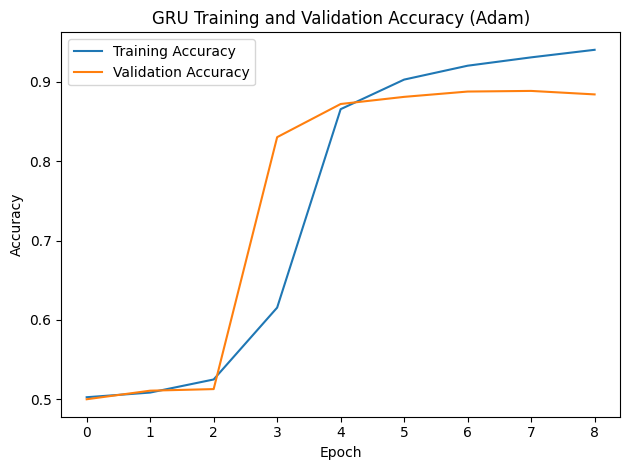

In [67]:
# Plot GRU training accuracy against validation accuracy
gru_h2l_bs64_acc_plot = plot_rnn_training_history(gru_h2l_bs64_history, metric='accuracy',
                                                   model_type='GRU', optimiser=' (Adam)')

313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 214ms/step
Classification Report for gru_h2l_bs64_model:
Accuracy: 88.79%
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      5000
           1       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



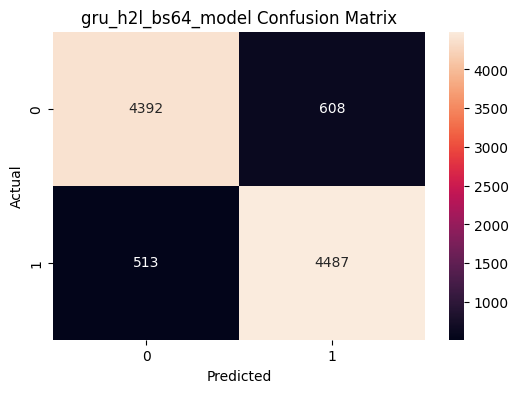

In [68]:
# Invoke function to evaluate models
m_gru_h2l_bs64_model = evaluate_deep_model(gru_h2l_bs64_model, X_test_dl, y_test_dl, cap="gru_h2l_bs64_model")

### LSTM Model (Adam)

Dropout is now increased from 0.3 to 0.5, and the unit is now stacked up with two layers [64,64]

```
dropout_rate=0.5
unit=[64, 64]
batch_size=64
early_stop, with patience=2
```
**NB: All other parameters remain the same**

In [70]:
# LSTM model (adam) and callbacks
lstm_h2l_bs64_result = build_rnn_model(
    model_type='lstm',
    units=[64, 64],
    dropout_rate=0.5,
    use_early_stop=True
)

# Access the model and callbacks
lstm_h2l_bs64_model = lstm_h2l_bs64_result['model']
lstm_h2l_bs64_callbacks = lstm_h2l_bs64_result['callbacks']

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [71]:
# Fit the model
lstm_h2l_bs64_history = lstm_h2l_bs64_model.fit(
    X_train_dl, y_train_dl,
    validation_data=(X_test_dl, y_test_dl),
    epochs=10,
    batch_size=64,
    callbacks=lstm_h2l_bs64_callbacks
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 490s 776ms/step - accuracy: 0.5006 - loss: 0.6936 - val_accuracy: 0.5112 - val_loss: 0.6928
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 503s 778ms/step - accuracy: 0.5046 - loss: 0.6936 - val_accuracy: 0.5000 - val_loss: 0.6998
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 502s 778ms/step - accuracy: 0.4987 - loss: 0.6942 - val_accuracy: 0.5000 - val_loss: 0.6932


#### LSTM History (Adam)
For batchsize=64, epochs=10, units=[64,64]
`LSTM tuned model`
- Plot loss and accuracy metric using adam optimizer
- Evaluate using Classifcation Report/Confusion

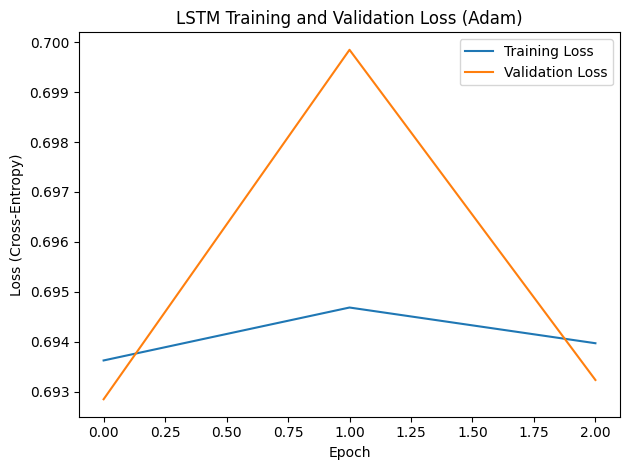

In [72]:
# Plot LSTM training loss against validation loss
lstm_h2l_bs64_loss_plot = plot_rnn_training_history(lstm_h2l_bs64_history, metric='loss',
                                                   model_type='LSTM', optimiser=' (Adam)')

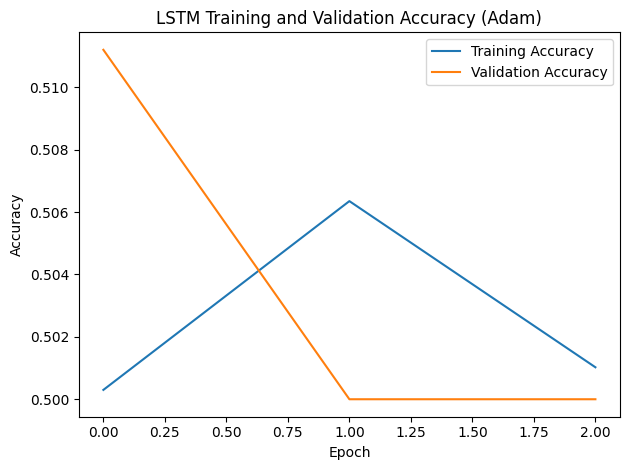

In [73]:
# Plot LSTM training accuracy against validation accuracy
lstm_h2l_bs64_acc_plot = plot_rnn_training_history(lstm_h2l_bs64_history, metric='accuracy',
                                                   model_type='LSTM', optimiser=' (Adam)')

313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 215ms/step
Classification Report for lstm_h2l_bs64_model:
Accuracy: 51.12%
              precision    recall  f1-score   support

           0       0.51      0.91      0.65      5000
           1       0.56      0.11      0.19      5000

    accuracy                           0.51     10000
   macro avg       0.53      0.51      0.42     10000
weighted avg       0.53      0.51      0.42     10000



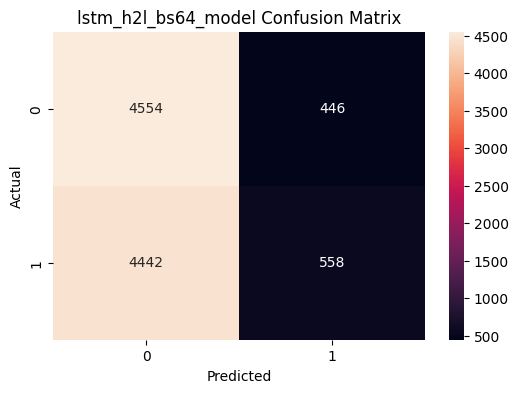

In [74]:
# Invoke function to evaluate models
m_lstm_h2l_bs64_model = evaluate_deep_model(lstm_h2l_bs64_model, X_test_dl, y_test_dl, cap="lstm_h2l_bs64_model")

### GRU Model (Adam)
Dropout is now increased from 0.3 to 0.5, and the unit is now stacked up with two layers [64,64]. embedding_dim now 128 from 64

```
dropout_rate=0.5
unit=[64, 64]
batch_size=128
early_stop, with patience=2
embedding_dim=128
```
**NB: All other parameters remain the same**

In [76]:
# GRU model (adam) and callbacks
gru_h2l_bs128_result = build_rnn_model(
    model_type='gru',
    embedding_dim=128,
    units=[64,64],
    dropout_rate=0.5,
    use_early_stop=True
)

# Access the model and callbacks
gru_h2l_bs128_model = gru_h2l_bs128_result['model']
gru_h2l_bs128_callbacks = gru_h2l_bs128_result['callbacks']

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [77]:
# Fit the model
gru_h2l_bs128_history = gru_h2l_bs128_model.fit(
    X_train_dl, y_train_dl,
    validation_data=(X_test_dl, y_test_dl),
    epochs=10,
    batch_size=128,
    callbacks=gru_h2l_bs128_callbacks
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 390s 1s/step - accuracy: 0.4965 - loss: 0.6939 - val_accuracy: 0.5000 - val_loss: 0.6949
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 442s 1s/step - accuracy: 0.5087 - loss: 0.6931 - val_accuracy: 0.5107 - val_loss: 0.6927
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 439s 1s/step - accuracy: 0.5275 - loss: 0.6860 - val_accuracy: 0.5008 - val_loss: 0.6933
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 379s 1s/step - accuracy: 0.5426 - loss: 0.6723 - val_accuracy: 0.5143 - val_loss: 0.7008


#### GRU History (Adam)
For batchsize=128, epochs=10, units=[64,64]
`GRU tuned model`
- Plot loss and accuracy metric using adam optimizer

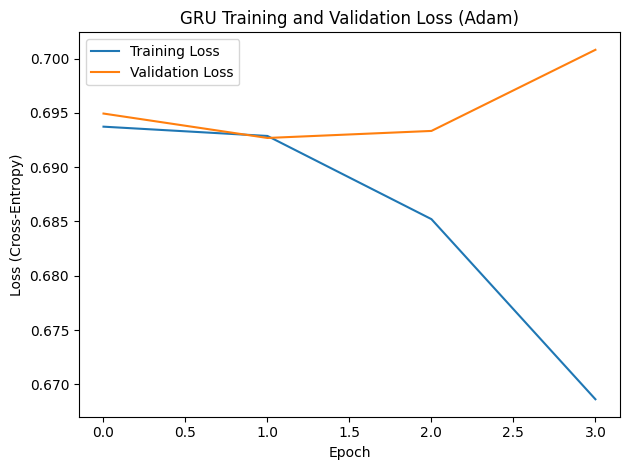

In [78]:
# Plot GRU training loss against validation loss
gru_h2l_bs128_loss_plot = plot_rnn_training_history(gru_h2l_bs128_history, metric='loss',
                                                   model_type='GRU', optimiser=' (Adam)')

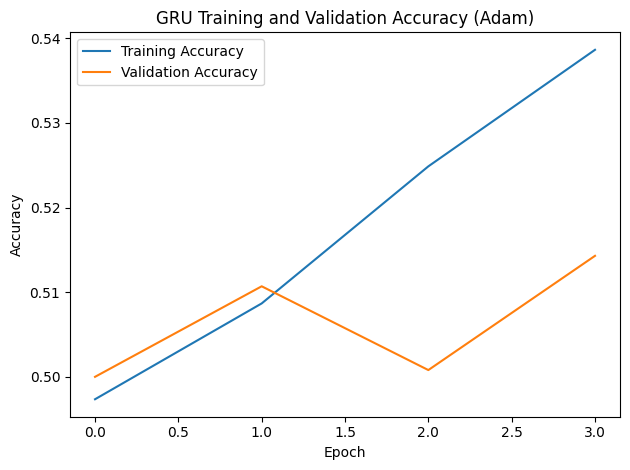

In [79]:
# Plot GRU training accuracy against validation accuracy
gru_h2l_bs128_acc_plot = plot_rnn_training_history(gru_h2l_bs128_history, metric='accuracy',
                                                   model_type='GRU', optimiser=' (Adam)')

313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 223ms/step
Classification Report for gru_h2l_bs128_model:
Accuracy: 51.07%
              precision    recall  f1-score   support

           0       0.51      0.95      0.66      5000
           1       0.59      0.07      0.13      5000

    accuracy                           0.51     10000
   macro avg       0.55      0.51      0.39     10000
weighted avg       0.55      0.51      0.39     10000



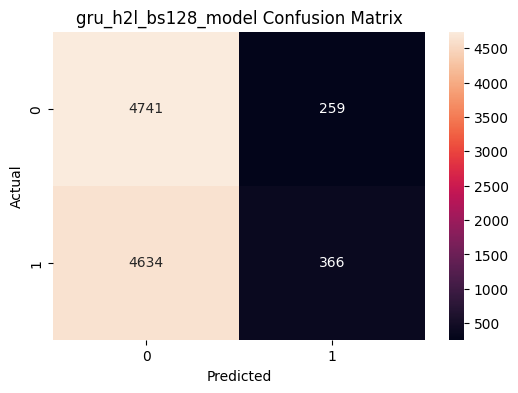

In [80]:
# Invoke function to evaluate models
m_gru_h2l_bs128_model = evaluate_deep_model(gru_h2l_bs128_model, X_test_dl, y_test_dl, cap="gru_h2l_bs128_model")

### LSTM Model (Adam)

Dropout is now increased from 0.3 to 0.5, and the unit is now stacked up with two layers [64,64]. embedding_dim now 128 from 64

```
dropout_rate=0.5
unit=[64, 64]
batch_size=128
early_stop, with patience=2
embedding_dim=128
```
**NB: All other parameters remain the same**

In [82]:
# LSTM model (adam) and callbacks
lstm_h2l_bs128_result = build_rnn_model(
    model_type='lstm',
    embedding_dim=128,
    units=[64,64],
    dropout_rate=0.5,
    use_early_stop=True
)

# Access the model and callbacks
lstm_h2l_bs128_model = lstm_h2l_bs128_result['model']
lstm_h2l_bs128_callbacks = lstm_h2l_bs128_result['callbacks']

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [83]:
# Fit the model
lstm_h2l_bs128_history = lstm_h2l_bs128_model.fit(
    X_train_dl, y_train_dl,
    validation_data=(X_test_dl, y_test_dl),
    epochs=10,
    batch_size=128,
    callbacks=lstm_h2l_bs128_callbacks
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 431s 1s/step - accuracy: 0.5011 - loss: 0.6938 - val_accuracy: 0.5135 - val_loss: 0.6926
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 441s 1s/step - accuracy: 0.5461 - loss: 0.6780 - val_accuracy: 0.7244 - val_loss: 0.5863
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 443s 1s/step - accuracy: 0.6791 - loss: 0.6132 - val_accuracy: 0.7167 - val_loss: 0.5898
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 435s 1s/step - accuracy: 0.7328 - loss: 0.5614 - val_accuracy: 0.8226 - val_loss: 0.4243
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 448s 1s/step - accuracy: 0.8456 - loss: 0.3792 - val_accuracy: 0.8581 - val_loss: 0.3357
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 439s 1s/step - accuracy: 0.8823 - loss: 0.2941 - val_accuracy: 0.8736 - val_loss: 0.3178
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 446s 1s/step - accuracy: 0.9034 - loss: 0.2540 - val_accuracy: 0.8773 - val_loss: 0.3048
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 438s 1s/step - accuracy: 0.9170 - loss: 0.2262 - val_accu

#### LSTM History (Adam)
For batchsize=128, epochs=10, units=[64,64]
`LSTM tuned model`
- Plot loss and accuracy metric using adam optimizer

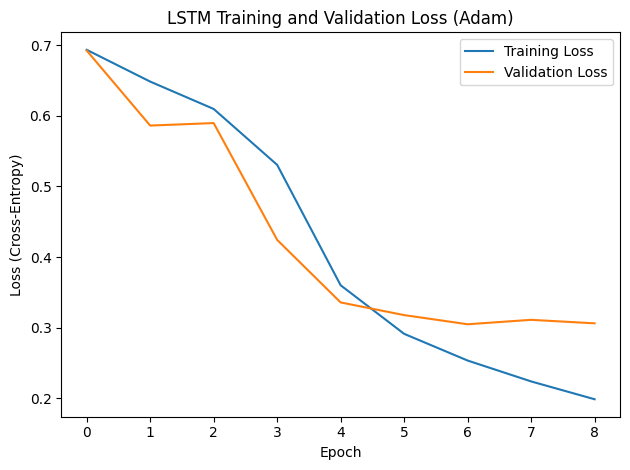

In [84]:
# Plot LSTM training loss against validation loss
lstm_h2l_bs128_loss_plot = plot_rnn_training_history(lstm_h2l_bs128_history, metric='loss',
                                                   model_type='LSTM', optimiser=' (Adam)')

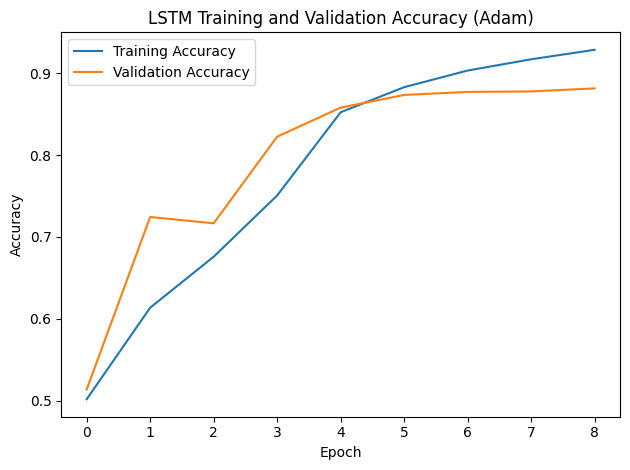

In [85]:
# Plot LSTM training accuracy against validation accuracy
lstm_h2l_bs128_acc_plot = plot_rnn_training_history(lstm_h2l_bs128_history, metric='accuracy',
                                                   model_type='LSTM', optimiser=' (Adam)')

313/313 ━━━━━━━━━━━━━━━━━━━━ 69s 219ms/step
Classification Report for lstm_h2l_bs128_model:
Accuracy: 87.73%
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      5000
           1       0.88      0.88      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



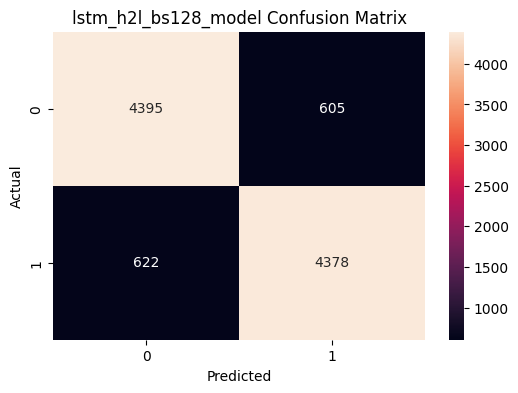

In [86]:
# Invoke function to evaluate models
m_lstm_h2l_bs128_model = evaluate_deep_model(lstm_h2l_bs128_model, X_test_dl, y_test_dl, cap="lstm_h2l_bs128_model")